# SMITH human disease transfer robustness

Participant-level human brain data remain controlled access. This notebook uses the real released per-seed metrics and checks that their aggregate summary agrees with the published de-identified table.

[Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/disease_section/04_SMITH_InHouse_Disease_Transfer_source.ipynb)

## Provenance

The code cell verifies the SHA-256 of every bundled result table. These files are copied from completed paper-workspace runs; they are not synthetic replacements for the manuscript outputs.

In [1]:
from pathlib import Path
import hashlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

def verify_fixture(relative_path, expected_sha256):
    path = ROOT / "reproducibility" / relative_path
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    assert digest == expected_sha256, f"Checksum mismatch for {path}: {digest}"
    print(f"Verified {relative_path} ({digest[:12]}...)")
    return path


## Analysis

Verified fixtures/inhouse_transfer_summary.csv (2adf61357af7...)
Verified fixtures/inhouse_transfer_per_seed_metrics.csv (843de9833c00...)


,comparison,n_seeds_released,delta_spearman_mean_released,delta_top64_mean_released,n_seeds_recomputed,delta_spearman_mean_recomputed,delta_top64_mean_recomputed,spearman_match,top64_match
0,AD-HC / X5704,5,0.108623,5.0,5,0.108623,5.0,True,True
1,AD-HC / X5789,5,0.082313,6.6,5,0.082313,6.6,True,True
2,AD-FC / X5665,5,0.131515,6.2,5,0.131515,6.2,True,True
3,PD-FC / X5215,5,0.183218,9.8,5,0.183218,9.8,True,True


/tmp/ipykernel_179590/1612398362.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values for _, values in groups], labels=[name for name, _ in groups], showmeans=True)
/tmp/ipykernel_179590/1612398362.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values for _, values in groups], labels=[name for name, _ in groups], showmeans=True)


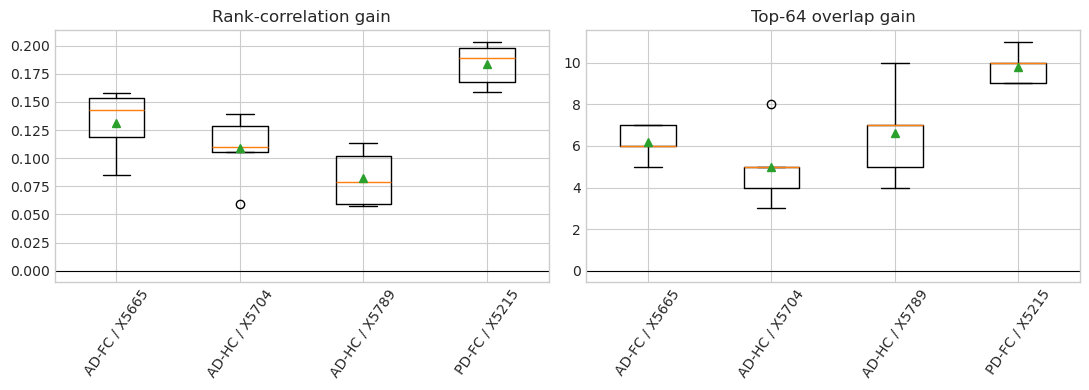

In [2]:
summary_path = verify_fixture("fixtures/inhouse_transfer_summary.csv", "2adf61357af7215d93ea48be992817fa74cb4daac942c02a26649034ad568f20")
seed_path = verify_fixture("fixtures/inhouse_transfer_per_seed_metrics.csv", "843de9833c00489e27e0f83d05421fb4c49beab566936af544b63871ef50acf5")
summary = pd.read_csv(summary_path)
per_seed = pd.read_csv(seed_path)
recomputed = (per_seed.groupby("comparison", as_index=False)
              .agg(n_seeds=("seed", "nunique"), delta_spearman_mean=("delta_spearman", "mean"), delta_top64_mean=("delta_top64", "mean")))
check = summary[["comparison", "n_seeds", "delta_spearman_mean", "delta_top64_mean"]].merge(recomputed, on="comparison", suffixes=("_released", "_recomputed"))
check["spearman_match"] = np.isclose(check["delta_spearman_mean_released"], check["delta_spearman_mean_recomputed"])
check["top64_match"] = np.isclose(check["delta_top64_mean_released"], check["delta_top64_mean_recomputed"])
assert check["spearman_match"].all() and check["top64_match"].all()
display(check)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for column, ax, title in [("delta_spearman", axes[0], "Rank-correlation gain"), ("delta_top64", axes[1], "Top-64 overlap gain")]:
    groups = per_seed.groupby("comparison")[column]
    ax.boxplot([values for _, values in groups], labels=[name for name, _ in groups], showmeans=True)
    ax.axhline(0, color="black", linewidth=0.8); ax.set_title(title); ax.tick_params(axis="x", rotation=55)
fig.tight_layout(); plt.show()


## Scope

The real per-seed table contains de-identified rank metrics only. Participant-level panels, UMAPs and spatial examples require authorized data access. The source summarization script is archived under `reproducibility/workflows/inhouse_disease/`.